# Transformer VQ-VAE training


In [26]:
#Import custom classes and libraries
from src.Data.data_loading import ParquetDataModule
from src.Data.data_loading import ParquetFeatureDataset
from src.Models.VQ_VAE_transformer import VQVAE_Transformer

import yaml
import numpy as np
from tqdm import tqdm
import torch
import lightning as L
import matplotlib.pyplot as plt


#Open config file
with open("Configs/config.yaml") as f:
    config = yaml.safe_load(f)

#Extract config info
#Directories
dirs_train = config["data"]["train_path"]
dirs_val = config["data"]["val_path"]
dirs_test = config["data"]["test_path"]

#Features
features_cols = config["data"]["features"]
max_part = config["data"]["max_part"]
prep = config["data"]["preprocessing"]

#VQVAE hyperparameters
input_dim = config["Transformer_VQVAE"]["input_dim"]
latent_dim = config["Transformer_VQVAE"]["latent_dim"]
codebook_size = config["Transformer_VQVAE"]["codebook_size"]
rot_trick = config["Transformer_VQVAE"]["rotation_trick"]
decay = config["Transformer_VQVAE"]["decay"]
beta = config["Transformer_VQVAE"]["beta"]
n_heads = config["Transformer_VQVAE"]["n_heads"]
n_layers = config["Transformer_VQVAE"]["n_layers"]

#Training hyperparameters
lr = config["training"]["lr"]
max_epochs = config["training"]["max_epochs"]
batch_size = config["training"]["batch_size"]


#Initialization of itarable dataset (train dataset) containing the constituents' features (eta, phi, pT)
#In particular I am currently using the first 2 parquet files
dataset_train = ParquetFeatureDataset(
    parquet_dirs=dirs_train,
    features=features_cols,
    max_particles=max_part,
    batch_size=batch_size,
    preprocessing=prep
)

#Validation dataset
#In particular I am currently using parquet files n. 5,6
dataset_val = ParquetFeatureDataset(
    parquet_dirs=dirs_val,
    features=features_cols,
    max_particles=max_part,
    batch_size=batch_size,
    preprocessing=prep
)

#Test dataset
#In particular I am currently using parquet file n. 7
dataset_test = ParquetFeatureDataset(
    parquet_dirs=dirs_test,
    features=features_cols,
    max_particles=max_part,
    batch_size=batch_size,
    preprocessing=prep
)

#Initialization of the lightining datamodule 
data_module = ParquetDataModule(
    parquet_dirs_train=dirs_train, 
    parquet_dirs_val=dirs_val,
    parquet_dirs_test=dirs_test,
    features=features_cols,
    window_particles=max_part,
    batch_size=batch_size,
    preprocessing=prep
    #num_workers=0
)

In [27]:
#Model
model_with_rot = VQVAE_Transformer(
    dec=decay,
    beta = beta,
    rot_trick=rot_trick,
    input_dim=input_dim,
    latent_dim=latent_dim,
    n_heads=n_heads,
    n_layers=n_layers,
    codebook_size=codebook_size,
    lr=lr
)

#Trainer (Lightning)
trainer_with_rot = L.Trainer(
    max_epochs=max_epochs,
    accelerator="auto",   #CPU/GPU automatic
    devices="auto",
    log_every_n_steps=10
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [28]:
trainer_with_rot.fit(model_with_rot, datamodule=data_module)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder │ TransformerEncoder │  2.4 M │ train │     0 │
│ 1 │ decoder │ TransformerDecoder │  2.4 M │ train │     0 │
│ 2 │ vq      │ VectorQuantize     │      0 │ train │     0 │
└───┴─────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 4.7 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 4.7 M                                                                                                
Total estimated model params size (MB): 18                                                                         
Modules in train mode: 92                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/francesco/anaconda3/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: 
The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/home/francesco/anaconda3/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: 
The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=10` reached.


### Codebook utilization

In [33]:
#Codebook utilization
codebook = []
model_with_rot.eval()

for batch, mask in dataset_test:
    
    with torch.no_grad():
        output = model_with_rot.forward(batch, mask)
    
    for element in output[2]:
        for particle in element:
            codebook.append(particle.item())

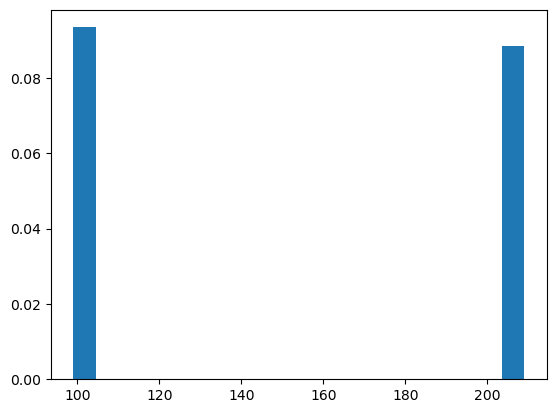

codebook utilization: 0.0078125


In [34]:
plt.hist(codebook, density=True, bins=20)
plt.show()

cb_util = list(set(codebook))
cb_util = len(cb_util) / 256
print(f'codebook utilization: {cb_util}')

### Reconstructed particle features

In [35]:
#Return the particles' features of all the events in a batch
def extract_features(x, mask):
    
    eta_list = []
    phi_list = []
    pT_list = []

    for i in range(x.shape[0]):
        valid = x[i][mask[i]]
        for eta, phi, pT in valid:
            eta_list.append(eta)
            phi_list.append(phi)
            pT_list.append(pT)
    
    return eta_list, phi_list, pT_list

In [36]:
#Create the reconstructed feature lists 
eta_list_rot = []
phi_list_rot = []
pT_list_rot = []

model_with_rot.eval()

for batch, mask in dataset_test:
    with torch.no_grad():
        output = model_with_rot.forward(batch, mask)
    
    feat = extract_features(output[0], mask)
    for i in range(len(feat[0])):
        eta_list_rot.append(feat[0][i])
        phi_list_rot.append(feat[1][i])
        pT_list_rot.append(feat[2][i])


In [8]:
#Create the original feature lists
   
eta_list_orig = []
phi_list_orig = []
pT_list_orig = []

for batch, mask in dataset_test:
    for i in range(batch.shape[0]):
        valid = batch[i][mask[i]]
        for eta, phi, pT in valid:
            eta_list_orig.append(eta)
            phi_list_orig.append(phi)
            pT_list_orig.append(pT)

/home/francesco/anaconda3/lib/python3.11/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges
/home/francesco/anaconda3/lib/python3.11/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges


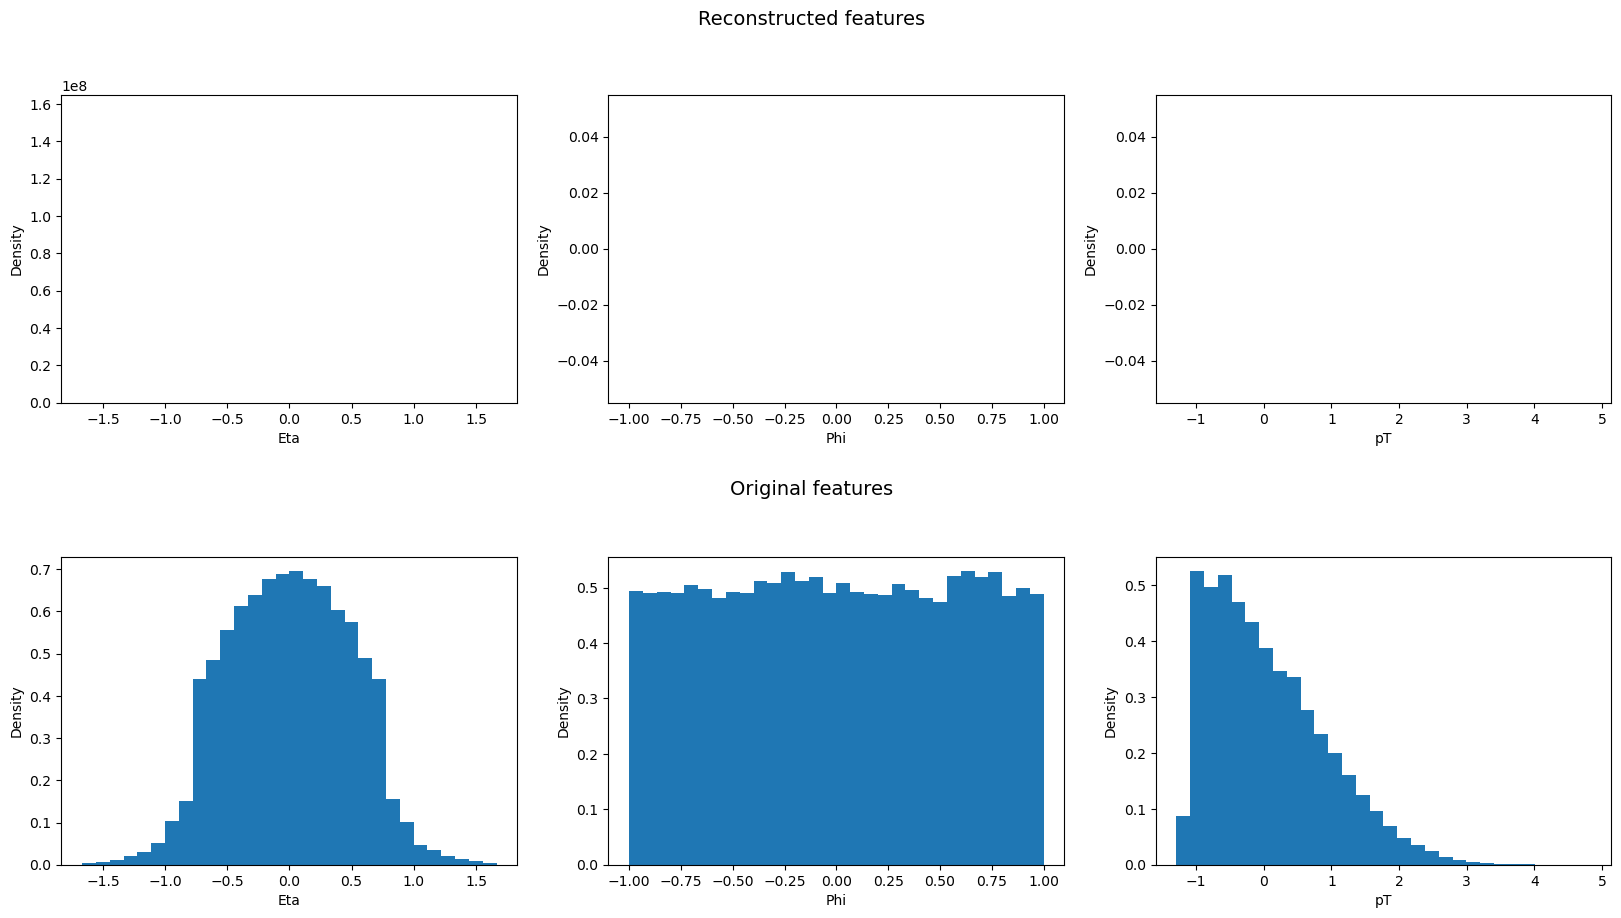

In [37]:
#Plot the reconstructed features and the original ones (preprocessed)
fig, ax = plt.subplots(2, 3, figsize=(20,10))

for i in range(3):
    ax[0, i].sharex(ax[1, i])

ax[0,0].hist(eta_list_rot, density=True, bins=30)
ax[0,0].set_xlabel("Eta")
ax[0,0].set_ylabel("Density")

ax[0,1].hist(phi_list_rot, density=True, bins=30)
ax[0,1].set_xlabel("Phi")
ax[0,1].set_ylabel("Density")

ax[0,2].hist(pT_list_rot, density=True, bins=30)
ax[0,2].set_xlabel("pT")
ax[0,2].set_ylabel("Density")

fig.text(0.5, 0.95, "Reconstructed features", ha='center', fontsize=14)
fig.subplots_adjust(hspace=0.5)
fig.text(0.5, 0.48, "Original features", ha='center', fontsize=14)

ax[1,0].hist(eta_list_orig, density=True, bins=30)
ax[1,0].set_xlabel("Eta")
ax[1,0].set_ylabel("Density")

ax[1,1].hist(phi_list_orig, density=True, bins=30)
ax[1,1].set_xlabel("Phi")
ax[1,1].set_ylabel("Density")

ax[1,2].hist(pT_list_orig, density=True, bins=30)
ax[1,2].set_xlabel("pT")
ax[1,2].set_ylabel("Density")


plt.show()

## Without rotation

In [10]:
#Model
model_no_rot = VQVAE_Transformer(
    dec=decay,
    beta = beta,
    rot_trick=False,
    input_dim=input_dim,
    latent_dim=latent_dim,
    n_heads=n_heads,
    n_layers=n_layers,
    codebook_size=codebook_size,
    lr=lr
)

#Trainer (Lightning)
trainer_no_rot = L.Trainer(
    max_epochs=max_epochs,
    accelerator="auto",   #CPU/GPU automatic
    devices="auto",
    log_every_n_steps=10
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [11]:
trainer_no_rot.fit(model_no_rot, datamodule=data_module)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder │ TransformerEncoder │  2.4 M │ train │     0 │
│ 1 │ decoder │ TransformerDecoder │  2.4 M │ train │     0 │
│ 2 │ vq      │ VectorQuantize     │      0 │ train │     0 │
└───┴─────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 4.7 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 4.7 M                                                                                                
Total estimated model params size (MB): 18                                                                         
Modules in train mode: 92                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=20` reached.


### Codebook utilization

In [12]:
#Codebook utilization
codebook = []
model_no_rot.eval()

for batch, mask in dataset_test:
    
    with torch.no_grad():
        output = model_no_rot.forward(batch, mask)
    
    for element in output[2]:
        for particle in element:
            codebook.append(particle)

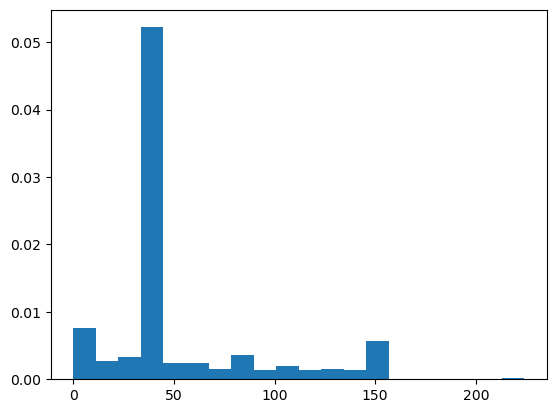

codebook utilization: 4356.0


In [13]:
plt.hist(codebook, density=True, bins=20)
plt.show()

cb_util = list(set(codebook))
cb_util = len(cb_util) / 256
print(f'codebook utilization: {cb_util}')

### Reconstructed particle features

In [14]:
#Return the particles' features of all the events in a batch
def extract_features(x, mask):
    
    eta_list = []
    phi_list = []
    pT_list = []

    for i in range(x.shape[0]):
        valid = x[i][mask[i]]
        for eta, phi, pT in valid:
            eta_list.append(eta)
            phi_list.append(phi)
            pT_list.append(pT)
    
    return eta_list, phi_list, pT_list

In [15]:
#Create the reconstructed feature lists 
eta_list_no_rot = []
phi_list_no_rot = []
pT_list_no_rot = []

model_no_rot.eval()

for batch, mask in dataset_test:
    with torch.no_grad():
        output = model_no_rot.forward(batch, mask)
    
    feat = extract_features(output[0], mask)
    for i in range(len(feat[0])):
        eta_list_no_rot.append(feat[0][i])
        phi_list_no_rot.append(feat[1][i])
        pT_list_no_rot.append(feat[2][i])


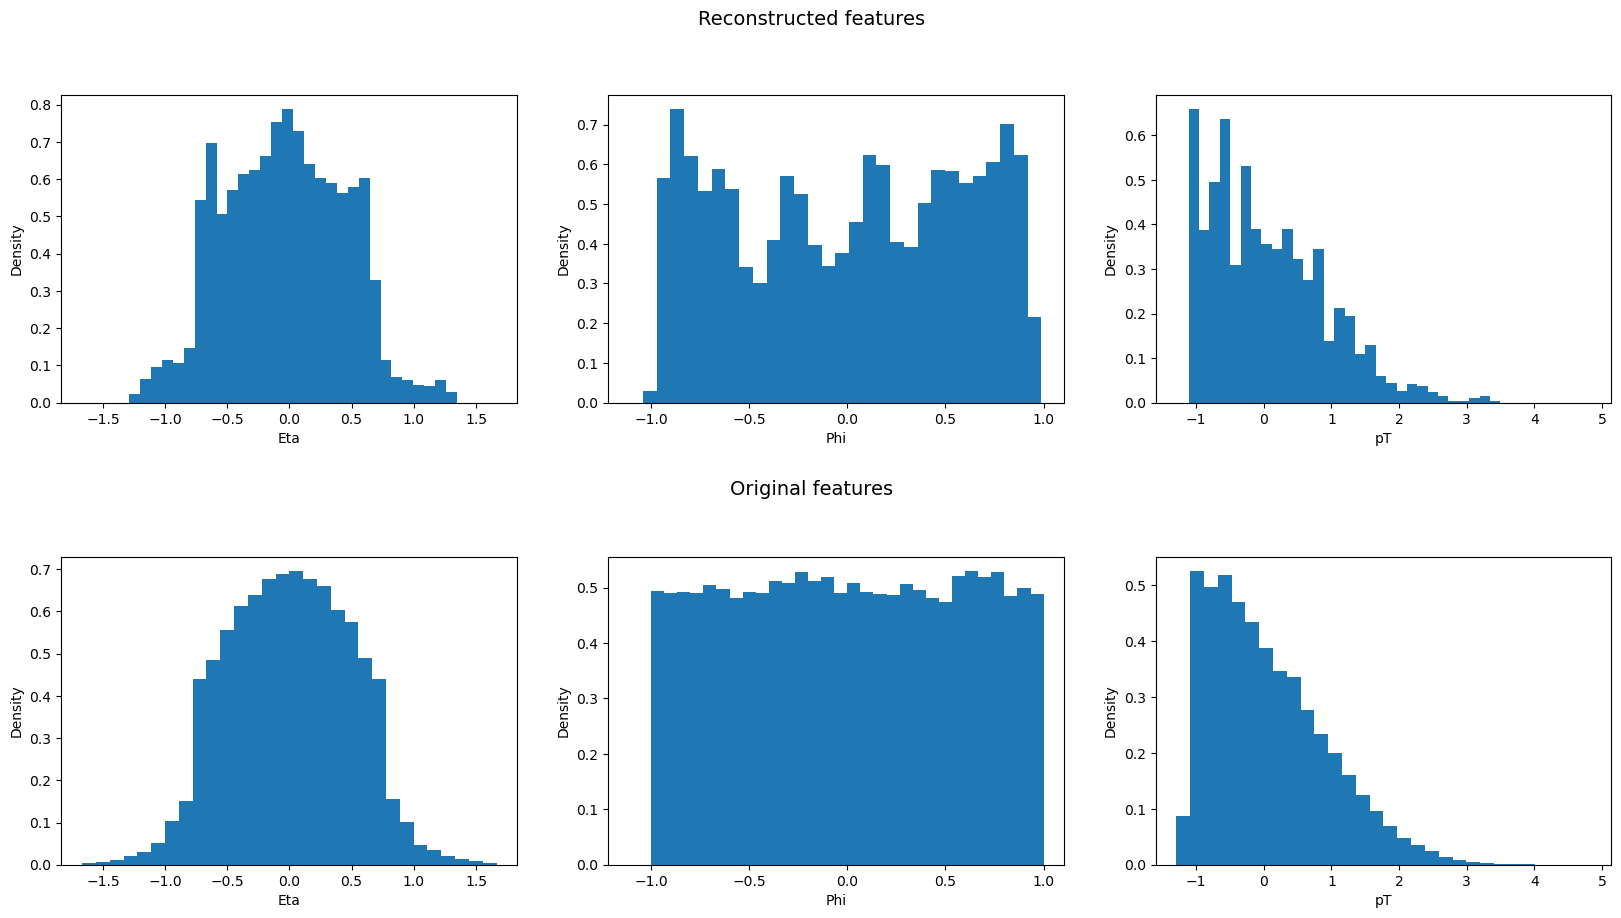

In [16]:
#Plot the reconstructed features and the original ones (preprocessed)
fig, ax = plt.subplots(2, 3, figsize=(20,10))

for i in range(3):
    ax[0, i].sharex(ax[1, i])

ax[0,0].hist(eta_list_no_rot, density=True, bins=30)
ax[0,0].set_xlabel("Eta")
ax[0,0].set_ylabel("Density")

ax[0,1].hist(phi_list_no_rot, density=True, bins=30)
ax[0,1].set_xlabel("Phi")
ax[0,1].set_ylabel("Density")

ax[0,2].hist(pT_list_no_rot, density=True, bins=30)
ax[0,2].set_xlabel("pT")
ax[0,2].set_ylabel("Density")

fig.text(0.5, 0.95, "Reconstructed features", ha='center', fontsize=14)
fig.subplots_adjust(hspace=0.5)
fig.text(0.5, 0.48, "Original features", ha='center', fontsize=14)

ax[1,0].hist(eta_list_orig, density=True, bins=30)
ax[1,0].set_xlabel("Eta")
ax[1,0].set_ylabel("Density")

ax[1,1].hist(phi_list_orig, density=True, bins=30)
ax[1,1].set_xlabel("Phi")
ax[1,1].set_ylabel("Density")

ax[1,2].hist(pT_list_orig, density=True, bins=30)
ax[1,2].set_xlabel("pT")
ax[1,2].set_ylabel("Density")


plt.show()

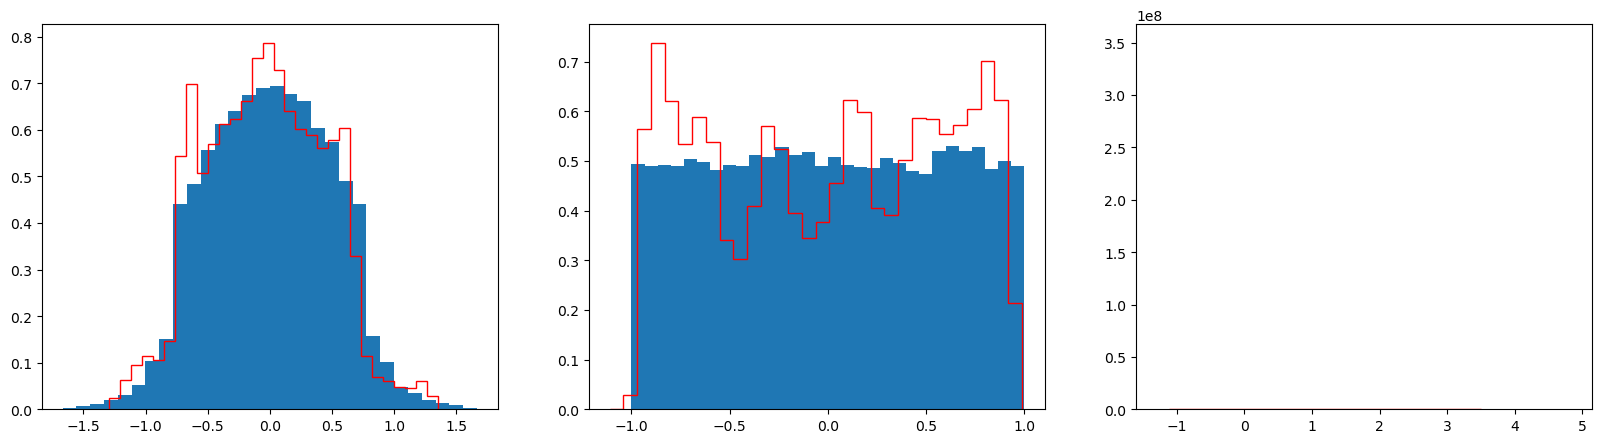

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(20,5))

ax[0].hist(eta_list_orig, density=True, bins=30, histtype='stepfilled')
ax[0].hist(eta_list_no_rot, density=True, bins=30, histtype='step', color = "red")
ax[0].hist(eta_list_rot, density=True, bins=30, histtype='step', color = "purple")

ax[1].hist(phi_list_orig, density=True, bins=30, histtype='stepfilled')
ax[1].hist(phi_list_no_rot, density=True, bins=30, histtype='step', color = "red")
ax[1].hist(phi_list_rot, density=True, bins=30, histtype='step', color = "purple")

ax[2].hist(pT_list_orig, density=True, bins=30, histtype='stepfilled')
ax[2].hist(pT_list_no_rot, density=True, bins=30, histtype='step', color = "red")
ax[2].hist(pT_list_rot, density=True, bins=30, histtype='step', color = "purple")


plt.show()